In [1]:
%load_ext autoreload
%autoreload 2

import ast
from pathlib import Path

from matplotlib import pyplot as plt

# Figure styling for paper readability (NeurIPS): larger type, regular weight, crisp lines.
plt.rcParams.update(
    {
        "font.size": 14,
        "axes.labelsize": 17,
        "axes.titlesize": 18,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 14,
        "legend.title_fontsize": 15,
        "font.weight": "normal",
        "axes.titleweight": "normal",
        "axes.labelweight": "normal",
        "axes.linewidth": 1.15,
        "xtick.major.width": 1.05,
        "ytick.major.width": 1.05,
        "grid.linewidth": 0.6,
        "grid.alpha": 0.22,
        "legend.framealpha": 0.92,
    }
)

import pandas as pd
import numpy as np
from IPython.display import display
from utils import get_eval_stats
import scipy

In [2]:
# PDB stem only (omit ``.pdb``): narrows pooled stats in trajectory cells elsewhere in this notebook.
# Final R² cell can also set ``r2_focus_protein`` to override without changing ``target_protein``.
target_protein = None
test_dir = "/home/shai/BLISS_Experiments/DRAKES/DRAKES/drakes_protein/fmif/eval_results/test/"
valid_dir = "/home/shai/BLISS_Experiments/DRAKES/DRAKES/drakes_protein/fmif/eval_results/validation/"
neurips_dir = "/home/shai/BLISS_Experiments/DRAKES/DRAKES/drakes_protein/fmif/eval_results/neurips/"
summary_func = np.mean

In [3]:
#################################
# Optional baselines from full eval CSVs (same split as neurips_figures3).

drakes_df = pd.read_csv(test_dir + "drakes_test.csv")
pretrained_df = pd.read_csv(test_dir + "pretrained_test.csv")

drakes_eval_stats = get_eval_stats(drakes_df, target_protein=target_protein, summary_func=summary_func)
pre_eval_stats = get_eval_stats(pretrained_df, target_protein=target_protein, summary_func=summary_func)

drakes_ddg_align = drakes_eval_stats.get("ddg_align")
pre_ddg_align = pre_eval_stats.get("ddg_align")

#################################

In [4]:
import re

base_dir = Path(neurips_dir)

# Neurips dumps are trajectory-only CSVs (no ddg_eval / ddg columns); augment stats below.


def neurips_merge_eval_stats(df, *, summary_fn):
    """Metrics available in eval_results/neurips: seq_recovery + spec_trajectory."""
    sub = df
    if target_protein is not None:
        sub = df[df["protein_name"] == target_protein + ".pdb"].copy()
    stats = get_eval_stats(sub, target_protein=None, summary_func=summary_fn)
    if "seq_recovery" in sub.columns:
        sr = sub["seq_recovery"].values.astype(float)
        stats["seq_recovery"] = summary_fn(sr)
        stats["seq_recovery_std"] = float(np.std(sr))
    if "spec_trajectory" in sub.columns:
        finals = []
        for x in sub["spec_trajectory"].values:
            if isinstance(x, (list, np.ndarray)):
                arr = np.asarray(x, dtype=float).ravel()
            else:
                if pd.isna(x):
                    continue
                try:
                    arr = np.array(ast.literal_eval(str(x).strip()), dtype=float).ravel()
                except Exception:
                    continue
            if arr.size >= 2:
                # Δ from pre-feedback → after first iteration (aligned across methods; multi-step dumps
                # still index the first spectral step at [1]; see reward_mean_se_first_feedback).
                finals.append(float(arr[1] - arr[0]))
        if finals:
            finals = np.asarray(finals, dtype=float)
            stats["traj_final"] = float(summary_fn(finals))
            stats["traj_final_std"] = float(np.std(finals))
            stats["pos_traj_final_prop"] = float(np.mean(finals > 0))
    return stats


def extract_int_from_name(name, key):
    match = re.search(rf"{key}=(\d+)", name)
    return int(match.group(1)) if match else None


def method_label_from_filename(name: str):
    if "spectral" in name:
        return "Spectral"
    if "max-mask" in name:
        return "Max-mask"
    return "unknown"


traj_col = "spec_trajectory"


def reward_mean_se_first_feedback(df):
    """Mean/SEM of Δ alignment reward for the first feedback step: traj[1] − traj[0].

    Pools like traj_full_comp: averages per protein, then SEM within protein combined across proteins.
    """
    df_work = df
    if target_protein is not None:
        df_work = df[df["protein_name"] == target_protein + ".pdb"]

    protein_names = sorted(set(df_work["protein_name"]))
    cluster_means = []
    std_errors = []
    for p in protein_names:
        df_p = df_work[df_work["protein_name"] == p]
        deltas = []
        for lst in df_p[traj_col].tolist():
            traj_p = np.asarray(eval(lst), dtype=float).ravel()
            if traj_p.size >= 2:
                deltas.append(float(traj_p[1] - traj_p[0]))
        if not deltas:
            continue
        deltas = np.asarray(deltas, dtype=float)
        cluster_means.append(float(np.mean(deltas)))
        std_errors.append(float(scipy.stats.sem(deltas)))

    if not cluster_means:
        return float("nan"), float("nan")

    n_proteins = len(cluster_means)
    std_errors = np.asarray(std_errors, dtype=float)
    return float(np.mean(cluster_means)), float(np.sqrt(np.sum(std_errors**2)) / n_proteins)


# One row per CSV (each file is a distinct mask count / run).
# NeurIPS figs here: pretrained runs only (exclude ``drakes_*``) and BON with N=1 only.
_all_neurips_csvs = sorted(base_dir.glob("*.csv"))
csv_paths = [
    p
    for p in _all_neurips_csvs
    if p.name.startswith("pretrained_test") and extract_int_from_name(p.name, "bon_N") == 1
]
stats_rows = []
for path in csv_paths:
    name = path.name
    df = pd.read_csv(path)
    st = neurips_merge_eval_stats(df, summary_fn=summary_func)
    if "spec_trajectory" in df.columns:
        tm, tsem = reward_mean_se_first_feedback(df)
        st["traj_final"] = tm
        st["traj_final_sem"] = tsem
        st.pop("traj_final_std", None)
    row = {
        "file": name,
        "method": method_label_from_filename(name),
        "cohort": "pretrained",
        "N": extract_int_from_name(name, "bon_N"),
        "feedbacksteps": extract_int_from_name(name, "feedbacksteps"),
        "maxspecorder": extract_int_from_name(name, "maxspecorder"),
        "masks": extract_int_from_name(name, "masks"),
        "num_samples": len(df),
    }
    row.update(st)
    stats_rows.append(row)

comparison_df = pd.DataFrame(stats_rows).sort_values(["maxspecorder", "method", "masks"], na_position="last")
source_df = comparison_df[["file", "method", "cohort", "N", "feedbacksteps", "maxspecorder", "masks", "num_samples"]]

metric_cols = [
    c
    for c in [
        "seq_recovery",
        "seq_recovery_std",
        "traj_final",
        "traj_final_sem",
        "pos_traj_final_prop",
        "ddg",
        "ddg_std",
        "ddg_align",
        "ddg_align_std",
        "pos_ddg_prop",
        "scrmsd",
        "scrmsd_std",
        "low_scrmsd_prop",
        "success_rate",
        "ll",
        "ll_std",
    ]
    if c in comparison_df.columns
]

print("Per-file runs under eval_results/neurips:")
display(source_df)

print(
    "\nEval stats (traj_final / traj_final_sem = mean Δ reward for first spectral feedback step, traj[1]−traj[0], pooled like traj_full_comp):"
)
display(comparison_df[["file", "method", "cohort", "N", "feedbacksteps", "maxspecorder", "masks", "num_samples"] + metric_cols])


Per-file runs under eval_results/neurips:


,file,method,cohort,N,feedbacksteps,maxspecorder,masks,num_samples
6,pretrained_test_ddg_bon_N=1_feedbacksteps=1_fe...,Max-mask,pretrained,1,1,20,1024.0,120
8,pretrained_test_ddg_bon_N=1_feedbacksteps=1_fe...,Max-mask,pretrained,1,1,20,2048.0,120
18,pretrained_test_ddg_bon_N=1_feedbacksteps=5_fe...,Max-mask,pretrained,1,5,20,2048.0,120
9,pretrained_test_ddg_bon_N=1_feedbacksteps=1_fe...,Max-mask,pretrained,1,1,20,4096.0,120
10,pretrained_test_ddg_bon_N=1_feedbacksteps=1_fe...,Max-mask,pretrained,1,1,20,8192.0,120
7,pretrained_test_ddg_bon_N=1_feedbacksteps=1_fe...,Max-mask,pretrained,1,1,20,16384.0,120
11,pretrained_test_ddg_bon_N=1_feedbacksteps=1_fe...,Spectral,pretrained,1,1,20,1024.0,120
13,pretrained_test_ddg_bon_N=1_feedbacksteps=1_fe...,Spectral,pretrained,1,1,20,2048.0,120
19,pretrained_test_ddg_bon_N=1_feedbacksteps=5_fe...,Spectral,pretrained,1,5,20,2048.0,120
14,pretrained_test_ddg_bon_N=1_feedbacksteps=1_fe...,Spectral,pretrained,1,1,20,4096.0,120



Eval stats (traj_final / traj_final_sem = mean Δ reward for first spectral feedback step, traj[1]−traj[0], pooled like traj_full_comp):


,file,method,cohort,N,feedbacksteps,maxspecorder,masks,num_samples,seq_recovery,seq_recovery_std,...,ddg_std,ddg_align,ddg_align_std,pos_ddg_prop,scrmsd,scrmsd_std,low_scrmsd_prop,success_rate,ll,ll_std
6,pretrained_test_ddg_bon_N=1_feedbacksteps=1_fe...,Max-mask,pretrained,1,1,20,1024.0,120,0.441562,0.083101,...,1.280897,0.352574,0.269142,0.566667,NaN,NaN,NaN,NaN,-146.923051,43.477728
8,pretrained_test_ddg_bon_N=1_feedbacksteps=1_fe...,Max-mask,pretrained,1,1,20,2048.0,120,0.439589,0.079393,...,1.274820,0.371133,0.258543,0.508333,1.065016,0.695038,0.933333,0.475000,-146.701738,42.566033
18,pretrained_test_ddg_bon_N=1_feedbacksteps=5_fe...,Max-mask,pretrained,1,5,20,2048.0,120,0.434582,0.082406,...,1.206920,0.516951,0.199413,0.675000,NaN,NaN,NaN,NaN,-146.292132,42.790036
9,pretrained_test_ddg_bon_N=1_feedbacksteps=1_fe...,Max-mask,pretrained,1,1,20,4096.0,120,0.439377,0.083334,...,1.337254,0.378689,0.272135,0.583333,NaN,NaN,NaN,NaN,-147.164688,43.269610
10,pretrained_test_ddg_bon_N=1_feedbacksteps=1_fe...,Max-mask,pretrained,1,1,20,8192.0,120,0.439398,0.081566,...,1.310918,0.381046,0.248242,0.575000,NaN,NaN,NaN,NaN,-146.539847,43.012703
7,pretrained_test_ddg_bon_N=1_feedbacksteps=1_fe...,Max-mask,pretrained,1,1,20,16384.0,120,0.435744,0.082242,...,1.241996,0.392210,0.244934,0.583333,NaN,NaN,NaN,NaN,-147.196171,43.156523
11,pretrained_test_ddg_bon_N=1_feedbacksteps=1_fe...,Spectral,pretrained,1,1,20,1024.0,120,0.440070,0.081644,...,1.256993,0.382873,0.243018,0.575000,1.101939,0.988865,0.941667,0.558333,-147.291641,43.160543
13,pretrained_test_ddg_bon_N=1_feedbacksteps=1_fe...,Spectral,pretrained,1,1,20,2048.0,120,0.436417,0.081733,...,1.262774,0.411668,0.241554,0.583333,NaN,NaN,NaN,NaN,-147.030077,42.813113
19,pretrained_test_ddg_bon_N=1_feedbacksteps=5_fe...,Spectral,pretrained,1,5,20,2048.0,120,0.430663,0.080806,...,1.222245,0.516559,0.198554,0.633333,NaN,NaN,NaN,NaN,-145.852269,43.035777
14,pretrained_test_ddg_bon_N=1_feedbacksteps=1_fe...,Spectral,pretrained,1,1,20,4096.0,120,0.437801,0.079537,...,1.296796,0.419221,0.225404,0.608333,1.149002,1.057375,0.933333,0.575000,-147.021369,42.679823


In [5]:
# Intentionally left non-plotting: keep only the final mask-sweep figure below.
# This cell prepares no additional outputs.
pass


Using 12 proteins shared across all compared files.
Saved figure to: /home/shai/NeuripsProtein2026/Figures/baseline_edit_position_selection_curve.pdf


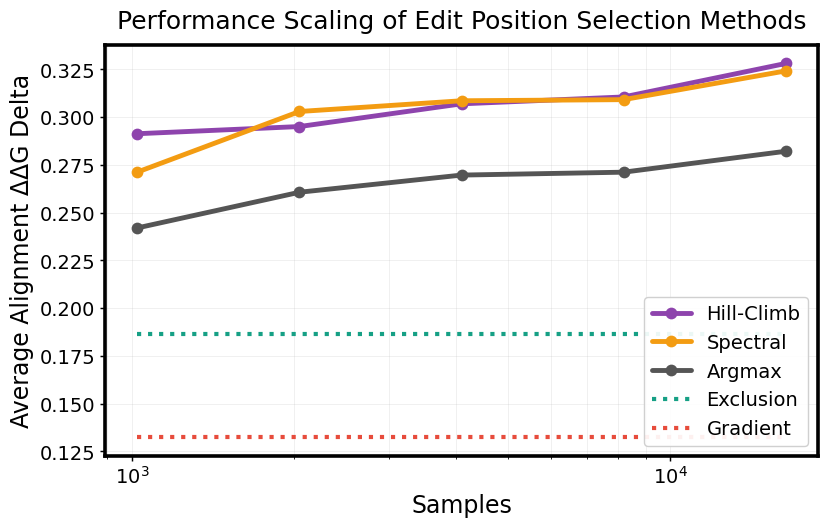

,method,method_label,budget,traj_final,se,n_files,seq_recovery,num_samples,n_common_proteins,paths
7,max-mask,Argmax,1024,0.241981,0.024911,1,0.441562,120,12,[pretrained_test_ddg_bon_N=1_feedbacksteps=1_f...
8,max-mask,Argmax,2048,0.260658,0.026448,1,0.439589,120,12,[pretrained_test_ddg_bon_N=1_feedbacksteps=1_f...
9,max-mask,Argmax,4096,0.269639,0.024739,1,0.439377,120,12,[pretrained_test_ddg_bon_N=1_feedbacksteps=1_f...
10,max-mask,Argmax,8192,0.271158,0.026554,1,0.439398,120,12,[pretrained_test_ddg_bon_N=1_feedbacksteps=1_f...
11,max-mask,Argmax,16384,0.282102,0.028888,1,0.435744,120,12,[pretrained_test_ddg_bon_N=1_feedbacksteps=1_f...
0,exclusion,Exclusion,20,0.186620,0.027177,1,0.435821,120,12,[pretrained_test_ddg_bon_N=1_feedbacksteps=5_f...
1,gradient,Gradient,20,0.132420,0.024844,1,0.441518,120,12,[pretrained_test_ddg_bon_N=1_feedbacksteps=1_f...
2,hill-climb,Hill-Climb,1024,0.291297,0.028245,1,0.437678,120,12,[pretrained_test_ddg_bon_N=1_feedbacksteps=1_f...
3,hill-climb,Hill-Climb,2048,0.295059,0.027547,1,0.436106,120,12,[pretrained_test_ddg_bon_N=1_feedbacksteps=1_f...
4,hill-climb,Hill-Climb,4096,0.306948,0.028441,1,0.434304,120,12,[pretrained_test_ddg_bon_N=1_feedbacksteps=1_f...


In [6]:
# Search-budget scaling: ``pretrained_test`` neurips CSVs with BON N=1 (see ``csv_paths`` in prior cell).
# Per CSV: reward_mean_se_first_feedback uses Δ = spec_trajectory[1] − [0] (first feedback iteration
# only); index convention matches spectral / max-mask / gradient runs and multi-step dumps (exclusion).
# Duplicate (method,budget) from both feedbacksteps=1 and 5: keep the CSV with smallest feedbacksteps.
# Per method+budget group: mean(y_f) and SEM(mean)=sqrt(sum(se_f^2))/n_files.
# For max-mask/spectral, budget=masks; for hill-climb, budget=hcits; exclusion uses 20 edits;
# gradient uses maxspecorder when masks/hcits are absent.
# Methods ``exclusion`` and ``gradient`` are drawn as horizontal baselines (constant vs sample budget).

BASELINE_METHODS = frozenset({"exclusion", "gradient"})

from collections import defaultdict

method_colors = {
    "Max-mask": "#2E86AB",
    "Spectral": "#F39C12",
    "Hill-Climb": "#8E44AD",
    "Exclusion": "#16A085",
    "Gradient": "#E74C3C",
    "unknown": "#777777",
}


def extract_feedback_method(name: str):
    m = re.search(r"feedbackmethod=([^_]+)", name)
    return m.group(1) if m else None


def pretty_method(name: str):
    if name == "max-mask":
        return "Argmax"
    if name == "spectral":
        return "Spectral"
    if name == "hill-climb":
        return "Hill-Climb"
    if name == "exclusion":
        return "Exclusion"
    if name == "gradient":
        return "Gradient"
    return name if name is not None else "unknown"


def extract_budget(name: str):
    masks = extract_int_from_name(name, "masks")
    if masks is not None:
        return masks
    hcits = extract_int_from_name(name, "hcits")
    if hcits is not None:
        return hcits
    m = re.search(r"feedbackmethod=([^_]+)", name)
    if m and m.group(1) == "gradient":
        return extract_int_from_name(name, "maxspecorder")
    return None


def aggregate_neurips_budget_curve_from_current_data(target_order=20, target_bon_n=1):
    grouped_files = defaultdict(list)

    for path in csv_paths:
        name = path.name
        if not name.startswith("pretrained_test"):
            continue
        method = extract_feedback_method(name)
        budget = extract_budget(name)
        order = extract_int_from_name(name, "maxspecorder")
        bon_n = extract_int_from_name(name, "bon_N")

        if method is None:
            continue

        if method == "exclusion":
            # Exclusion baseline is defined with a fixed 20 edit positions.
            budget = 20
            if order != target_order or bon_n != target_bon_n:
                continue
        elif method == "gradient":
            # Gradient baseline curve: budget key from filename (typically maxspecorder); same filters as exclusion (no feedbacksteps gate).
            budget = extract_budget(name)
            if budget is None:
                continue
            if order != target_order or bon_n != target_bon_n:
                continue
        else:
            if budget is None:
                continue
            if order != target_order or bon_n != target_bon_n:
                continue

        grouped_files[(method, budget)].append(path)

    def _preferred_csv(paths):
        if len(paths) <= 1:
            return paths
        return [min(paths, key=lambda p: extract_int_from_name(p.name, "feedbacksteps"))]

    for key in list(grouped_files.keys()):
        grouped_files[key] = _preferred_csv(grouped_files[key])

    # Compare only proteins that exist in every included file.
    selected_paths = sorted({p for files in grouped_files.values() for p in files})
    common_proteins = None
    for p in selected_paths:
        df = pd.read_csv(p)
        proteins = set(df["protein_name"].dropna().astype(str).tolist())
        common_proteins = proteins if common_proteins is None else (common_proteins & proteins)

    if target_protein is not None:
        target_name = target_protein + ".pdb"
        common_proteins = {target_name} if (common_proteins is None or target_name in common_proteins) else set()

    common_proteins = set() if common_proteins is None else common_proteins
    print(f"Using {len(common_proteins)} proteins shared across all compared files.")

    rows = []
    for (method, budget), files in sorted(grouped_files.items(), key=lambda x: (x[0][0], x[0][1])):
        per_file_y = []
        per_file_se = []
        seq_rec = []
        sample_count = 0

        for f in sorted(files):
            df = pd.read_csv(f)
            if common_proteins:
                df = df[df["protein_name"].astype(str).isin(common_proteins)].copy()
            else:
                df = df.iloc[0:0].copy()

            if len(df) == 0:
                continue

            y_f, se_f = reward_mean_se_first_feedback(df)
            per_file_y.append(float(y_f))
            per_file_se.append(float(se_f))
            seq_rec.append(neurips_merge_eval_stats(df, summary_fn=summary_func).get("seq_recovery"))
            sample_count += len(df)

        if len(per_file_y) == 0:
            continue

        arr_y = np.asarray(per_file_y, dtype=float)
        arr_se = np.asarray(per_file_se, dtype=float)
        y = float(np.mean(arr_y))
        se = float(np.sqrt(np.sum(arr_se**2)) / len(arr_se))

        rows.append(
            {
                "method": method,
                "method_label": pretty_method(method),
                "budget": budget,
                "traj_final": y,
                "se": se,
                "n_files": len(per_file_y),
                "seq_recovery": float(np.nanmean(seq_rec)) if len(seq_rec) else None,
                "num_samples": sample_count,
                "n_common_proteins": len(common_proteins),
                "paths": [p.name for p in sorted(files)],
            }
        )

    return rows


rows = aggregate_neurips_budget_curve_from_current_data()
fig, ax = plt.subplots(figsize=(8.5, 5.5))

# Plot/legend order: highest last point first (top-to-bottom legend matches line ranking).
method_to_pts = {}
for method in sorted(set(r["method"] for r in rows)):
    pts = sorted([r for r in rows if r["method"] == method], key=lambda r: r["budget"])
    if pts:
        method_to_pts[method] = pts

ordered_methods = sorted(
    method_to_pts,
    key=lambda m: method_to_pts[m][-1]["traj_final"],
    reverse=True,
)

scaled_budgets = sorted({r["budget"] for r in rows if r["method"] not in BASELINE_METHODS})

for method in ordered_methods:
    pts = method_to_pts[method]
    label = pts[0]["method_label"]
    color = method_colors.get(label, method_colors.get(method, "#555555"))
    xs = np.asarray([r["budget"] for r in pts], dtype=float)
    ys = np.asarray([r["traj_final"] for r in pts], dtype=float)

    if method in BASELINE_METHODS:
        y = float(ys[-1])
        if len(scaled_budgets) > 0:
            x_min = float(min(scaled_budgets))
            x_max = float(max(scaled_budgets))
        else:
            x_min = float(xs.min())
            x_max = float(xs.max())

        ax.hlines(
            y,
            x_min,
            x_max,
            label=f"{label}",
            color=color,
            linewidth=3.0,
            linestyle=":",
            zorder=4,
        )
        continue

    ax.plot(
        xs,
        ys,
        label=label,
        color=color,
        linewidth=3.5,
        marker="o",
        markersize=7.0,
        # markerfacecolor="white",
        markeredgecolor=color,
        markeredgewidth=1.45,
        solid_capstyle="round",
        zorder=5,
    )

            
    for _sp in ax.spines.values():
        _sp.set_linewidth(2.6)

ax.set_xscale("log", base=10)
ax.set_xlabel("Samples")
ax.set_ylabel("Average Alignment ΔΔG Delta")
ax.set_title("Performance Scaling of Edit Position Selection Methods", y=1.02)
ax.grid(True, which="both", alpha=0.22)
ax.legend(loc="lower right", frameon=True)

plt.tight_layout()
output_pdf = Path.home() / "NeuripsProtein2026" / "Figures" / "baseline_edit_position_selection_curve.pdf"
output_pdf.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(output_pdf, format="pdf", bbox_inches="tight")
print(f"Saved figure to: {output_pdf}")
plt.show()

display(pd.DataFrame(rows).sort_values(["method_label", "budget"]))
